/home/antoine/anaconda3/lib/python3.12/site-packages/networkx/utils/backends.py:258: RuntimeWarning: networkx backend defined more than once: cugraph
  backends = _get_backends("networkx.backends")
/home/antoine/anaconda3/lib/python3.12/site-packages/networkx/utils/backends.py:259: RuntimeWarning: networkx backend defined more than once: cugraph
  backend_info = _get_backends("networkx.backend_info", load_and_call=True)


cuda
Training 1/3
Epoch [0/50], d_loss: 1.1988214254379272, g_loss: -3.4405598640441895, batch time: -3.844151496887207
Epoch [1/50], d_loss: 0.7176293134689331, g_loss: -3.7282938957214355, batch time: -4.202746868133545
Epoch [2/50], d_loss: 0.40869617462158203, g_loss: -4.07612943649292, batch time: -4.332836151123047
Epoch [3/50], d_loss: 0.3628391623497009, g_loss: -3.7021594047546387, batch time: -4.006885528564453
Epoch [4/50], d_loss: 0.3772730827331543, g_loss: -3.638174533843994, batch time: -3.9322569370269775
Epoch [5/50], d_loss: 0.2854984998703003, g_loss: -3.9687917232513428, batch time: -4.199990749359131
Epoch [6/50], d_loss: 0.28100350499153137, g_loss: -4.20597505569458, batch time: -4.450621128082275
Epoch [7/50], d_loss: 0.2648521959781647, g_loss: -4.121346950531006, batch time: -4.341204643249512
Epoch [8/50], d_loss: 0.21471229195594788, g_loss: -4.47872257232666, batch time: -4.660843849182129
Epoch [9/50], d_loss: 0.205658420920372, g_loss: -4.319737911224365,

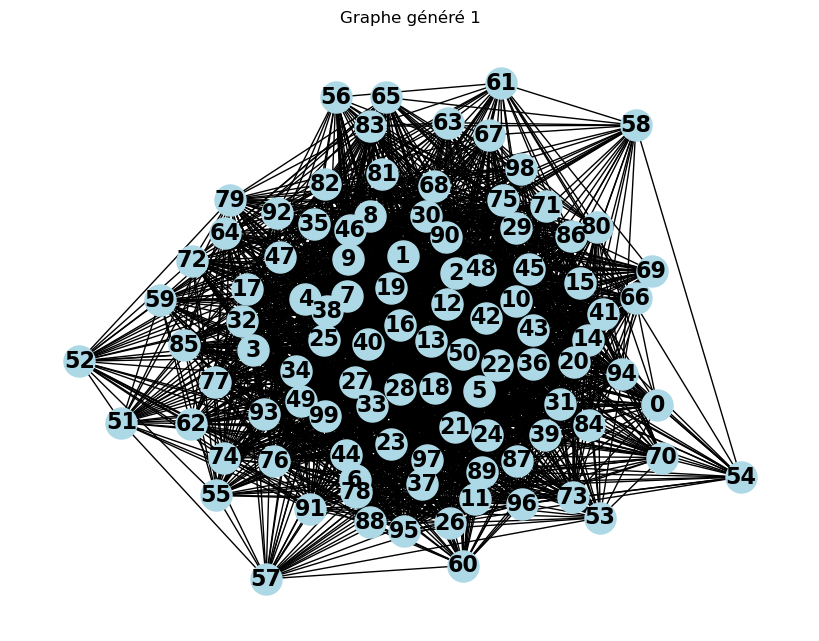

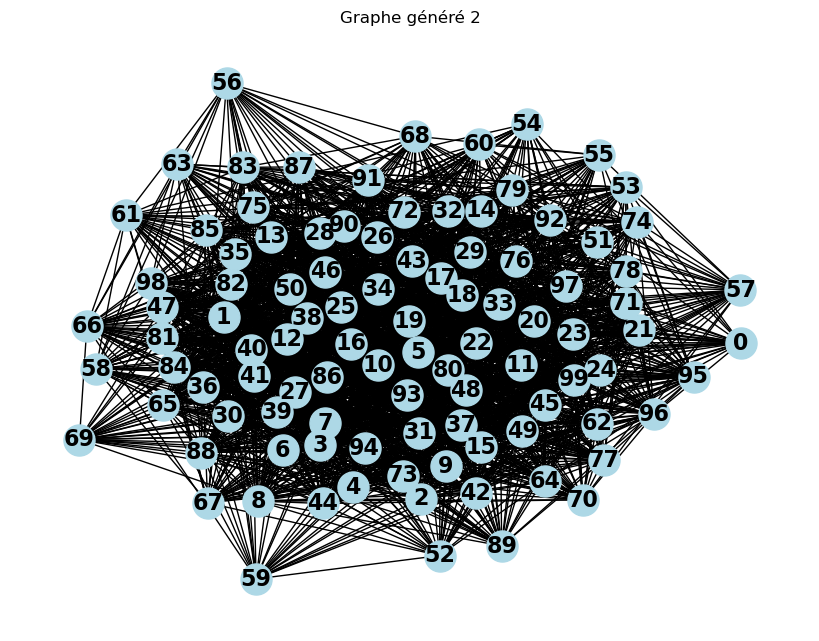

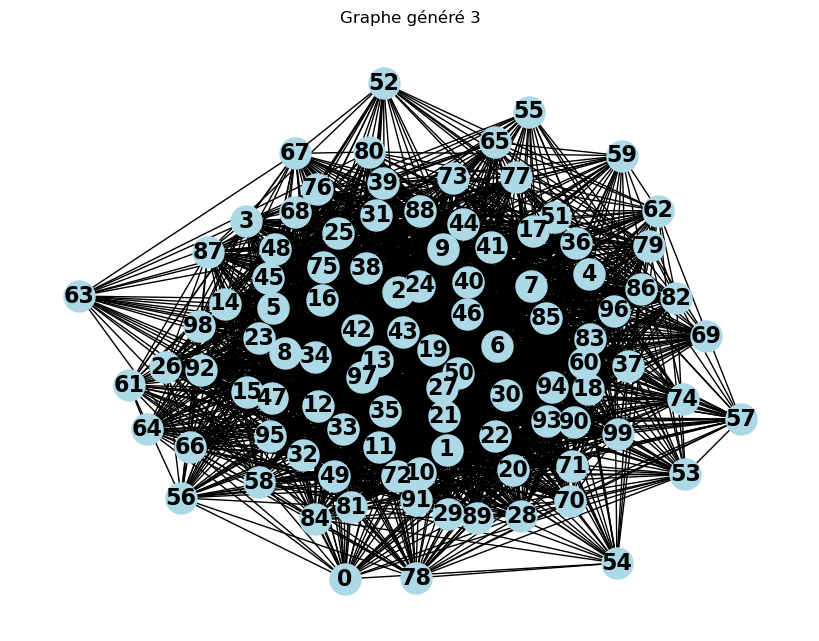

Training 2/3
Epoch [0/50], d_loss: 1.2558085918426514, g_loss: -3.7701194286346436, batch time: -4.338743209838867
Epoch [1/50], d_loss: 1.0843911170959473, g_loss: -4.14785099029541, batch time: -4.443927764892578
Epoch [2/50], d_loss: 1.0225471258163452, g_loss: -3.769376754760742, batch time: -4.191909313201904
Epoch [3/50], d_loss: 1.0012075901031494, g_loss: -4.1602888107299805, batch time: -4.426200866699219
Epoch [4/50], d_loss: 0.9300056099891663, g_loss: -3.9553701877593994, batch time: -4.318694591522217
Epoch [5/50], d_loss: 0.8968899250030518, g_loss: -4.387166500091553, batch time: -4.616292953491211
Epoch [6/50], d_loss: 0.8236854076385498, g_loss: -4.202268123626709, batch time: -4.480354309082031
Epoch [7/50], d_loss: 0.7561523914337158, g_loss: -4.410366535186768, batch time: -4.636988639831543
Epoch [8/50], d_loss: 0.7016986012458801, g_loss: -4.713855743408203, batch time: -4.907231330871582
Epoch [9/50], d_loss: 0.6104351282119751, g_loss: -4.148361682891846, batch 

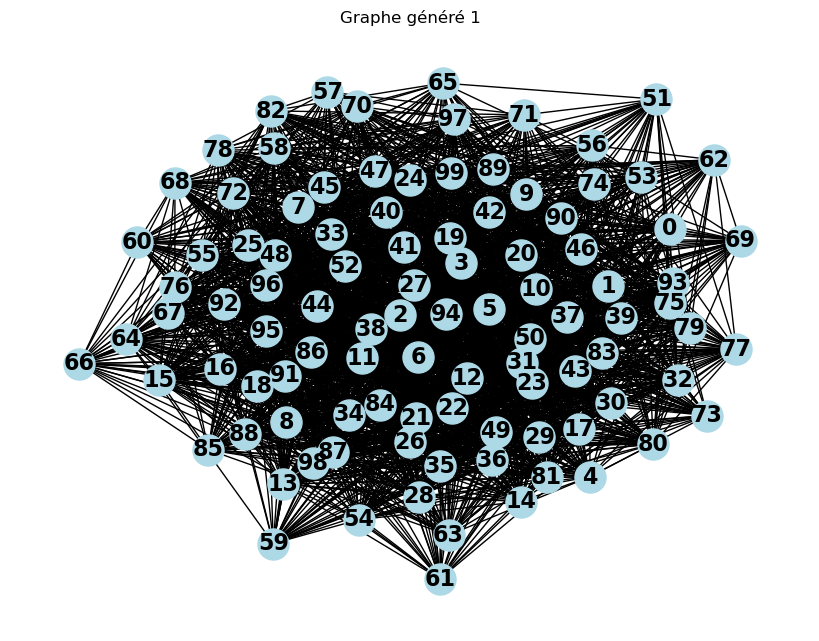

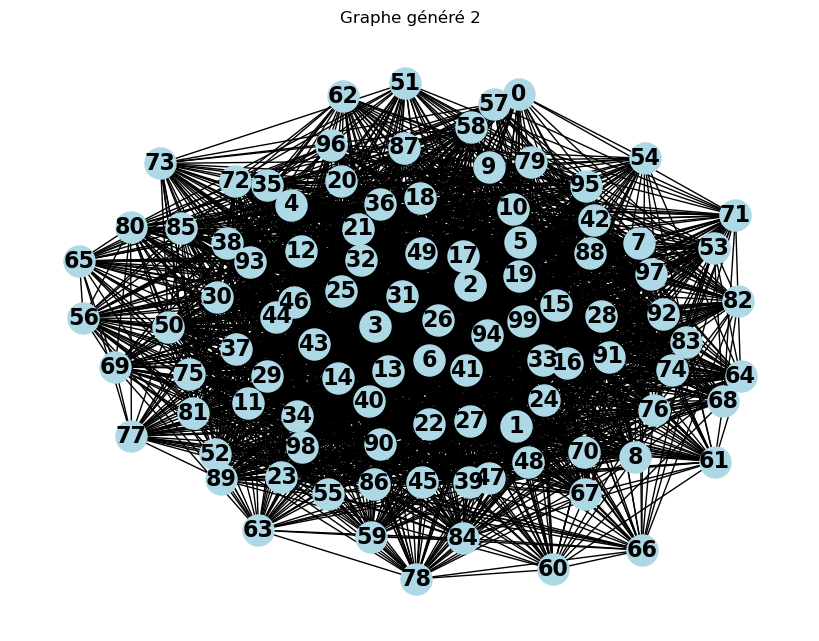

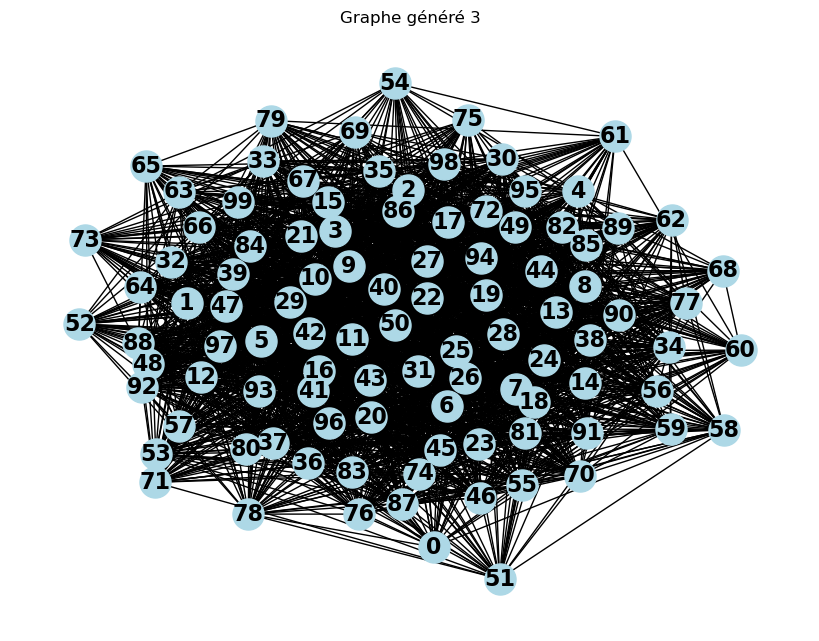

Training 3/3
Epoch [0/50], d_loss: 1.359511137008667, g_loss: -3.459897994995117, batch time: -4.1981000900268555
Epoch [1/50], d_loss: 1.2969516515731812, g_loss: -3.7365148067474365, batch time: -4.1662797927856445
Epoch [2/50], d_loss: 1.1938531398773193, g_loss: -3.6667749881744385, batch time: -4.123176097869873
Epoch [3/50], d_loss: 1.213719129562378, g_loss: -3.8889963626861572, batch time: -4.2331085205078125
Epoch [4/50], d_loss: 1.1091511249542236, g_loss: -3.771144151687622, batch time: -4.217432975769043
Epoch [5/50], d_loss: 1.1021103858947754, g_loss: -4.242740631103516, batch time: -4.539559364318848
Epoch [6/50], d_loss: 1.0208454132080078, g_loss: -4.016509056091309, batch time: -4.35931396484375
Epoch [7/50], d_loss: 0.9512673616409302, g_loss: -4.427680015563965, batch time: -4.703470230102539
Epoch [8/50], d_loss: 0.8993833065032959, g_loss: -4.153128623962402, batch time: -4.405782699584961
Epoch [9/50], d_loss: 0.7950647473335266, g_loss: -4.017236232757568, batch

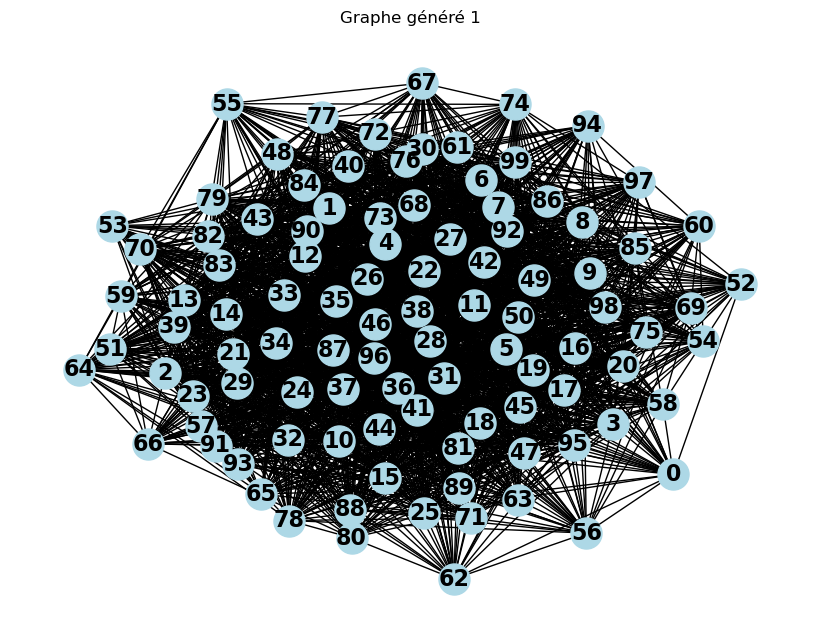

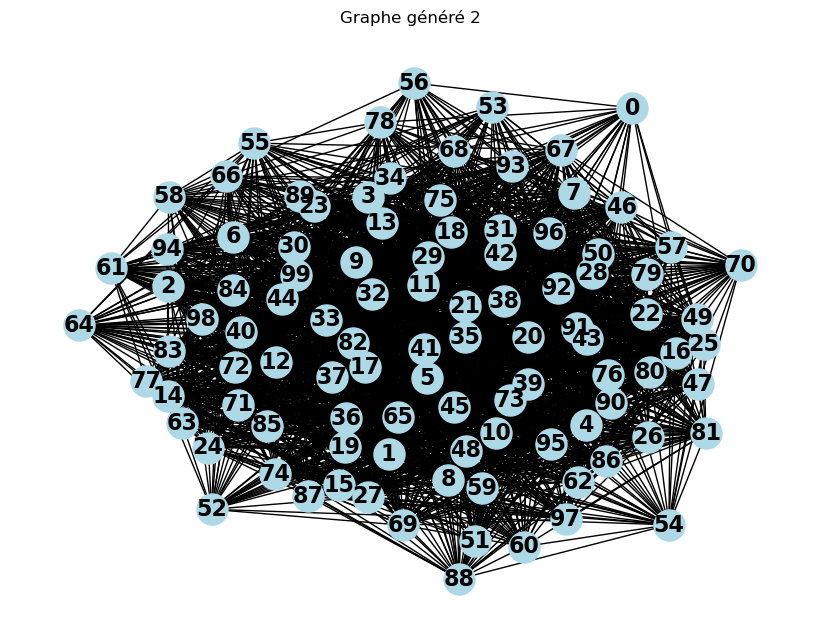

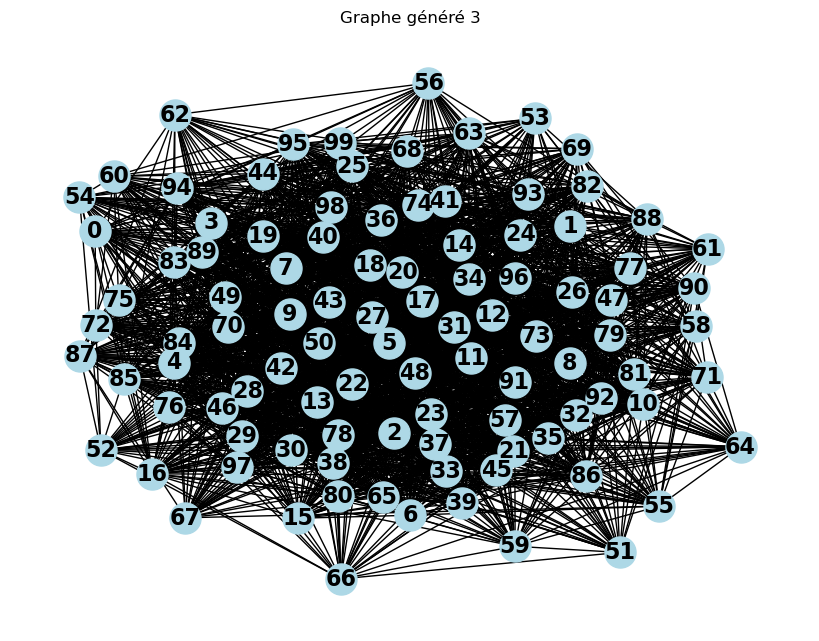

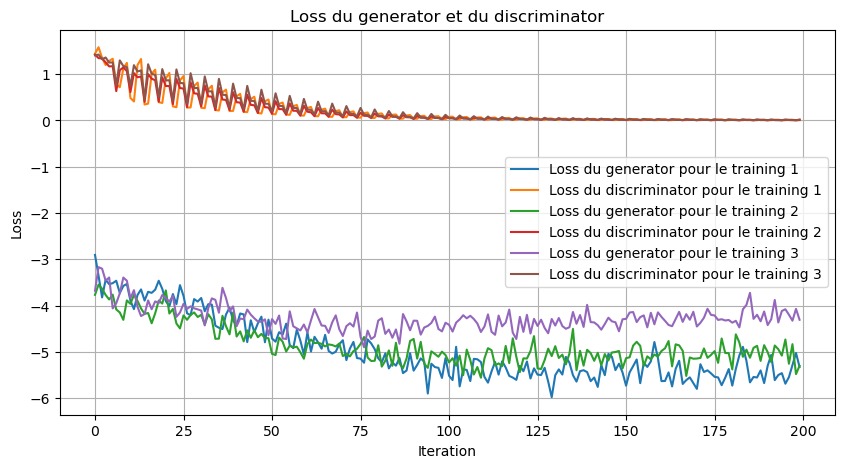

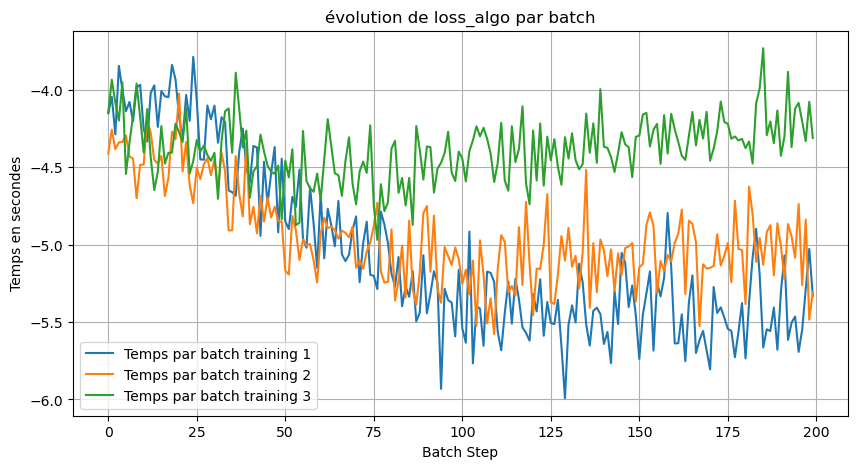

In [1]:
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import time
import matplotlib.pyplot as plt

class Generator(nn.Module):
    def __init__(self, n_nodes):
        super(Generator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, n_nodes * n_nodes)
        )

    def forward(self, z):
        output = self.fc(z)
        adj_matrix = output.view(-1, self.n_nodes, self.n_nodes)
        adj_matrix = (adj_matrix + adj_matrix.transpose(1, 2)) / 2
        adj_matrix = torch.sigmoid(adj_matrix)
        adj_matrix = adj_matrix * (1 - torch.eye(self.n_nodes)).to(adj_matrix.device)
        return adj_matrix

class Discriminator(nn.Module):
    def __init__(self, n_nodes):
        super(Discriminator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes * n_nodes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, adj_matrix):
        x = adj_matrix.view(-1, self.n_nodes * self.n_nodes)
        return self.fc(x)

def generate_erdos_renyi(n, p=0.5):
    G = nx.erdos_renyi_graph(n, p)
    adj_matrix = nx.to_numpy_array(G)
    return adj_matrix

def generate_barabasi_albert(n, m=50):
    G = nx.barabasi_albert_graph(n, m)
    adj_matrix = nx.to_numpy_array(G)
    return adj_matrix

def maximal_clique_time_loss(adj_matrix):
    batch_size, n_nodes, _ = adj_matrix.size()
    time_loss = torch.zeros(batch_size).to(adj_matrix.device)
    for i in range(batch_size):
        matrice = (adj_matrix[i] > 0.5).float() + adj_matrix[i] - adj_matrix[i].detach()
        G = nx.from_numpy_array(matrice.detach().cpu().numpy())
        start_time = time.time()
        maximal_cliques = list(nx.find_cliques(G))
        end_time = time.time()
        time_loss[i] = end_time - start_time
        
    final_loss = -torch.sum(time_loss)
    return final_loss

def visualize_generated_graphs(generator, n_samples=3, n_nodes=100):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, n_nodes).to(device='cuda')
        fake_adj = (generator(z) > 0.5).float()
        
        for i in range(n_samples):
            adj_matrix = fake_adj[i].cpu().numpy()
            G = nx.from_numpy_array(adj_matrix)
            
            plt.figure(figsize=(8, 6))
            nx.draw(G, with_labels=True, node_color='lightblue', 
                   node_size=500, font_size=16, font_weight='bold')
            plt.title(f'Graphe généré {i+1}')
            plt.show()

def train_multiple(n_nodes=100, n_graphs=256, num_epochs=1000, batch_size=32, num_trainings=5, loss_algo=maximal_clique_time_loss):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    all_g_losses = []
    all_d_losses = []
    all_batch_times = []
    
    graph_dataset = []
    for _ in range(n_graphs // 2):
        graph_dataset.append(generate_erdos_renyi(n_nodes))
    for _ in range(n_graphs // 2):
        graph_dataset.append(generate_barabasi_albert(n_nodes))
    
    for training in range(num_trainings):
        print(f"Training {training + 1}/{num_trainings}")
        
        generator = Generator(n_nodes).to(device)
        discriminator = Discriminator(n_nodes).to(device)
        
        g_optimizer = optim.Adam(generator.parameters(), lr=0.0001, weight_decay=1e-5)
        d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001, weight_decay=1e-5)
        
        g_losses = []
        d_losses = []
        batch_times = []
        
        for epoch in range(num_epochs):
            for i in range(0, n_graphs, batch_size):
                batch_graphs_np = np.array(graph_dataset[i:i+batch_size])
                real_graphs = torch.tensor(batch_graphs_np, dtype=torch.float32).to(device)
                
                z = torch.randn(batch_size, n_nodes).to(device)
                fake_adj = generator(z)
                
                times = []
                graphs = []
                for j in range(batch_size):
                    single_graph = fake_adj[j].unsqueeze(0)
                    time_value = loss_algo(single_graph)
                    times.append(float(time_value.item()))
                    graphs.append(fake_adj[j].cpu().detach().numpy())
                
                d_optimizer.zero_grad()
                d_real = discriminator(real_graphs)
                d_fake = discriminator(fake_adj.detach())
                d_loss = -torch.mean(torch.log(d_real) + torch.log(1 - d_fake))
                d_loss.backward()
                d_optimizer.step()
                
                g_optimizer.zero_grad()
                g_fake = discriminator(fake_adj)
                time_algo = loss_algo(fake_adj)
                batch_times.append(float(time_algo.item()))
                
                g_loss = -torch.mean(torch.log(1-g_fake)) + time_algo
                g_loss.backward()
                g_optimizer.step()
                
                g_losses.append(g_loss.item())
                d_losses.append(d_loss.item())
            
            if epoch % 1 == 0:
                print(f'Epoch [{epoch}/{num_epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}, batch time: {batch_times[-1]}')
                torch.save(generator.state_dict(), f'generator_hard_{training}.pth')
        
        
        sorted_pairs = sorted(zip(times, graphs), key=lambda x: x[0], reverse=True)
        hardest_times, hardest_graphs = zip(*sorted_pairs[:batch_size//2])
        
        replace_indices = sorted(range(i, min(i+batch_size, n_graphs)), key=lambda idx: times[idx-i])[:batch_size//2]
        for idx, graph in zip(replace_indices, hardest_graphs):
            graph_dataset[idx] = graph
        
        all_g_losses.append(g_losses)
        all_d_losses.append(d_losses)
        all_batch_times.append(batch_times)
        
        
        torch.save(generator.state_dict(), f'generator_hard_final_{training}.pth')
        
        
        visualize_generated_graphs(generator, n_samples=3, n_nodes=n_nodes)   
    
    plt.figure(figsize=(10, 5))
    for i in range(num_trainings):
        plt.plot(all_g_losses[i], label=f'Loss du generator pour le training {i+1}')
        plt.plot(all_d_losses[i], label=f'Loss du discriminator pour le training {i+1}')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss du generator et du discriminator')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
    plt.figure(figsize=(10, 5))
    for i in range(num_trainings):
        plt.plot(all_batch_times[i], label=f'Temps par batch training {i+1}')
    plt.xlabel('Batch Step')
    plt.ylabel('Temps en secondes')
    plt.title('évolution de loss_algo par batch')
    plt.legend()
    plt.grid(True)
    plt.show()


train_multiple(n_nodes=100, n_graphs=128, num_epochs=50, batch_size=32, num_trainings=3)#5 et 5